In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

In [ ]:
df=pd.read_csv("/content/HAM10000_metadata.csv")

In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [ ]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


class distribution

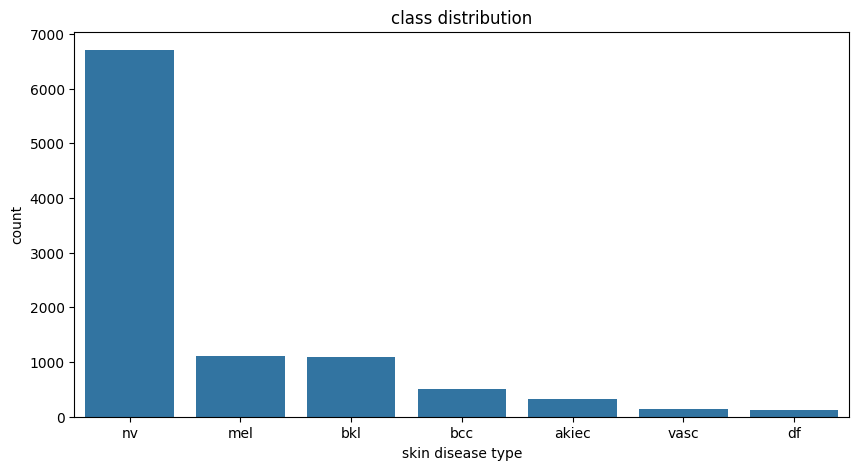

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='dx',order=df['dx'].value_counts().index)
plt.title('class distribution')
plt.xlabel('skin disease type')
plt.ylabel('count')
plt.show()

mapping

In [ ]:
label_map = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions'
}
df['dx_full'] = df['dx'].map(label_map)

class imbalance

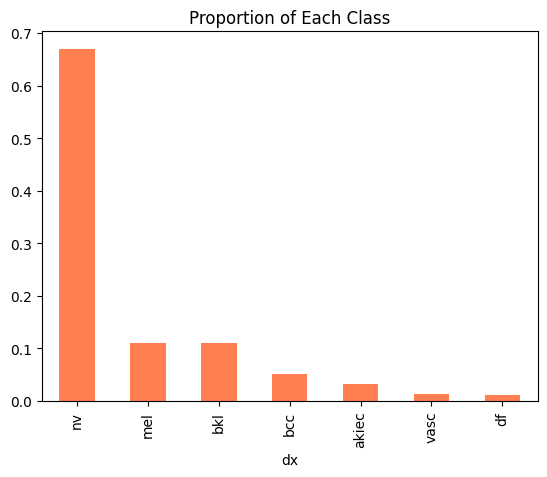

In [ ]:
df['dx'].value_counts(normalize=True).plot(kind='bar', color='coral')
plt.title("Proportion of Each Class")
plt.show()
#there is class imbalance as nv dominates - so we have to add class weights

gender and age eda

Text(0.5, 0, 'Age')

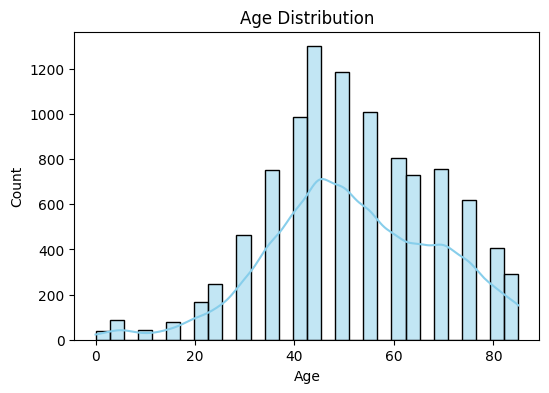

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")

/tmp/ipython-input-14-1156827315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='Set2')


Text(0.5, 1.0, 'Gender Distribution')

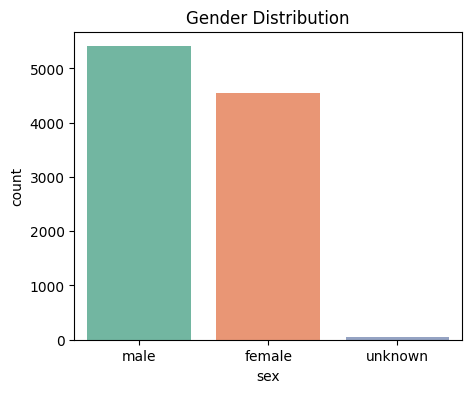

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='sex', palette='Set2')
plt.title("Gender Distribution")

load images (there are 2  separate folders)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/My Drive/skin_project/HAM10000_images.zip" -d "/content/HAM10000_images"

Streaming output truncated to the last 5000 lines.
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024306.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024307.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024308.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024309.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024310.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024311.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024312.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024313.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024314.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024315.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_0024316.jpg  
  inflating: /content/HAM10000_images/HAM10000_images_part_1/ISIC_002

In [ ]:
image_dirs = [
    "/content/HAM10000_images/HAM10000_images_part_1",
    "/content/HAM10000_images/HAM10000_images_part_2"
]

metadata_path = "/content/drive/My Drive/skin_project/HAM10000_metadata.csv"

In [ ]:
def find_image_path(image_id, image_dirs):
    for image_dir in image_dirs:
        image_path = os.path.join(image_dir, f"{image_id}.jpg")
        if os.path.exists(image_path):
            return image_path
    return None

In [ ]:
df['image_path'] = df['image_id'].apply(lambda x: find_image_path(x, image_dirs))

In [ ]:
print("Missing images:", df['image_path'].isnull().sum())

Missing images: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

image preprocessing

In [ ]:
from PIL import Image
import numpy as np

In [ ]:
# Example: Load just 100 images to test
df_small = df.sample(100, random_state=42)

image_size = (224, 224)  # Standard CNN input size
X = []
y = []

In [ ]:
for i, row in df_small.iterrows():
    try:
        img = Image.open(row['image_path']).resize(image_size)
        img_array = np.array(img) / 255.0  # Normalize pixel values
        if img_array.shape == (224, 224, 3):  # Ensure it's RGB
            X.append(img_array)
            y.append(row['dx'])  # 'dx' is the disease label
    except Exception as e:
        print(f"Error loading image {row['image_path']}: {e}")

In [ ]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

X shape: (100, 224, 224, 3)
y shape: (100,)
Unique labels: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


convert text labels  to integers

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Convert integers to one-hot encoded vectors

In [ ]:
y_categorical = to_categorical(y_encoded)

print("Example:", y[0], "→", y_encoded[0], "→", y_categorical[0])
print("Shape:", y_categorical.shape)

Example: mel → 4 → [0. 0. 0. 0. 1. 0. 0.]
Shape: (100, 7)


building CNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_categorical.shape[1], activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,615 (111.78 KB)

 Trainable params: 28,615 (111.78 KB)

 Non-trainable params: 0 (0.00 B)

train

In [ ]:
history = model.fit(
    X, y_categorical,
    epochs=5,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3460 - loss: 1.8681 - val_accuracy: 0.7000 - val_loss: 1.6697
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4901 - loss: 1.7047 - val_accuracy: 0.7000 - val_loss: 1.3048
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6174 - loss: 1.3950 - val_accuracy: 0.7000 - val_loss: 1.0565
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6408 - loss: 1.3298 - val_accuracy: 0.7000 - val_loss: 1.0364
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6128 - loss: 1.3752 - val_accuracy: 0.7000 - val_loss: 1.1006


plotting accuracy when training is only on 100 samples

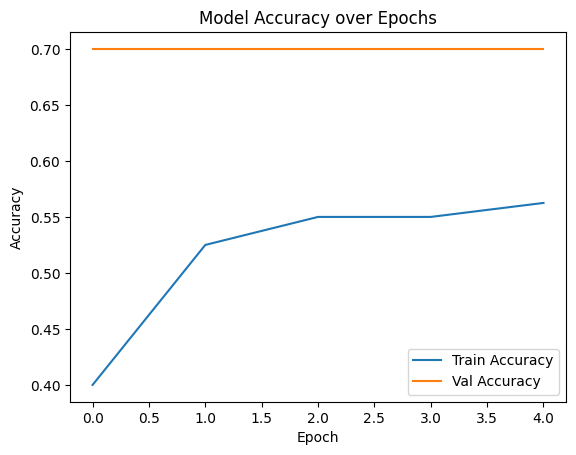

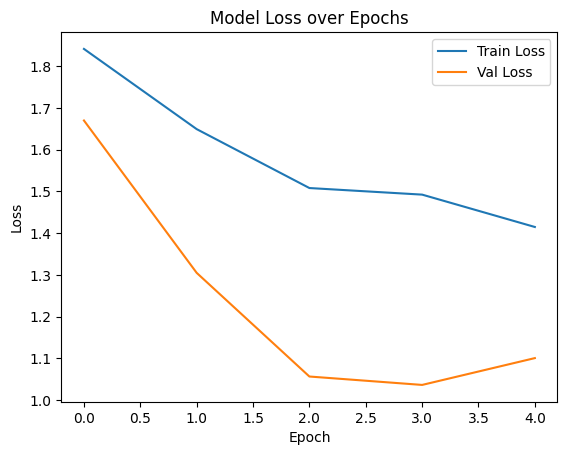

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

to get more accuracy , we are now usingall  10,000+ images instead of just 100

We’ll use a generator so RAM doesn’t crash

In [ ]:
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
image_dirs = [
    "/content/HAM10000_images/HAM10000_images_part_1",
    "/content/HAM10000_images/HAM10000_images_part_2"
]
def find_image_path(image_id, image_dirs):
    for directory in image_dirs:
        full_path = os.path.join(directory, f"{image_id}.jpg")
        if os.path.exists(full_path):
            return full_path
    return None

df['image_path'] = df['image_id'].apply(lambda x: find_image_path(x, image_dirs))

In [ ]:
missing_count = df['image_path'].isnull().sum()
print(f"Missing images: {missing_count}")

Missing images: 0


In [ ]:
df['dx'] = df['dx'].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)

 Setup ImageDataGenerator (Augmentation + Split)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=(img_size, img_size),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=(img_size, img_size),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
df = df.dropna(subset=['image_path'])  # Drop rows with missing images

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
import numpy as np

class weights compute for imbalance handling

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['dx']),
    y=train_df['dx']
)
class_weights_dict = dict(zip(np.unique(train_df['dx']), class_weights))

using high accuracy pretrained model - efficientnet80

In [ ]:
# Load pretrained EfficientNet
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # Freeze base

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Add top layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
num_classes = train_df['dx'].nunique()
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

Add EarlyStopping + Checkpoint

In [ ]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_effnet_model.h5", monitor='val_accuracy', save_best_only=True)

train model

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
  1/251 ━━━━━━━━━━━━━━━━━━━━ 1:39:31 24s/step - accuracy: 0.0000e+00 - loss: 2.0194

KeyboardInterrupt: 

In [ ]:
print(df['image_path'].head())

In [ ]:
print("All paths valid:", all([os.path.exists(p) for p in df['image_path']]))

In [ ]:
import os

# Your base folder (adjust if needed)
folder1 = "/content/HAM10000_images/HAM10000_images_part_1"
folder2 = "/content/HAM10000_images/HAM10000_images_part_2"

# Combine both paths to one searchable list
all_image_paths = [os.path.join(folder1, f) for f in os.listdir(folder1) if f.endswith('.jpg')]
all_image_paths += [os.path.join(folder2, f) for f in os.listdir(folder2) if f.endswith('.jpg')]

# Create a dict: {image_id: full_path}
id_to_path = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}

# Now map correct paths to DataFrame
df['image_path'] = df['image_id'].map(id_to_path)

# Verify it's fixed
print("Sample path:", df['image_path'].iloc[0])
print("Exists?", os.path.exists(df['image_path'].iloc[0]))
print("Missing images:", df['image_path'].isna().sum())

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('best_effnet_model.h5')

In [ ]:
model.summary()

sample prediction

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load model
model = load_model('best_effnet_model.h5')

# Get class labels from your generator
class_labels = list(train_gen.class_indices.keys())

# Pick one test image from your dataframe
sample_img_path = df['image_path'].iloc[0]  # Or filter by label if you want

# Preprocess the image
img = image.load_img(sample_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array / 255.0, axis=0)  # Normalize and batchify

# Predict
preds = model.predict(img_array)
predicted_index = np.argmax(preds[0])
predicted_label = class_labels[predicted_index]

# Output
print(f"predicted label: {class_labels[predicted_index]}")  # Maps to actual disease
print(f"Confidence: {preds[0][predicted_index]:.2f}")


GRADCAM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# GRADCAM generator
def get_gradcam_heatmap(model, img_array, class_index, last_conv_layer_name):
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# Full GRADCAM display function
def display_gradcam(img_path, model, class_labels, img_size=224, last_conv_layer_name='top_conv'):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    input_array = np.expand_dims(img_array / 255.0, axis=0)

    # Predict
    preds = model.predict(input_array)
    class_index = int(np.argmax(preds[0]))
    class_name = class_labels[class_index]
    confidence = preds[0][class_index]

    print(f"Predicted: {class_name} ({confidence:.2f})")

    # Generate heatmap
    heatmap = get_gradcam_heatmap(model, input_array, class_index, last_conv_layer_name)
    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Overlay on image
    superimposed_img = heatmap_colored * 0.4 + img_array
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Display
    plt.figure(figsize=(8, 6))
    plt.title(f"GRADCAM: {class_name}")
    plt.axis('off')
    plt.imshow(superimposed_img)
    plt.show()


In [ ]:
sample_img_path = df['image_path'].iloc[0]

In [ ]:
class_labels = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

In [ ]:
display_gradcam(sample_img_path, model, class_labels)

In [ ]:
from google.colab import files
files.download("best_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("best_model.h5")

In [ ]:
import json
labels = ['akiec','bcc','bkl','df','mel','nv','vasc']  # update if your order differs
with open("/content/labels.json", "w") as f:
    json.dump(labels, f)